# Overlapping Neighborhoods — Parent-Child Role Assignment (V2)

**V2 — Universal Pair-Type Support:** All five relationship types participate in role
assignment by default. The user controls inclusion/exclusion per type. Cross-bench pairs
are gated by a configurable vertical separation threshold.

Uses the `OverlappingNeighborhoodRoles` class from
`src/well_data/well_role_assignment.py`.

---

### Neighbor Relationship Types — ALL participate in role assignment
| Type | Alignment | Bench | Confidence | Gate |
|---|---|---|---|---|
| `parallel_same_bench` | parallel_like | same | **high** | distance only |
| `cross_formation` | parallel_like | different | **medium** | distance + vertical |
| `cross_orientation` | perpendicular | any | **medium** | distance only |
| `oblique_same_bench` | oblique | same | **medium** | distance only |
| `oblique_cross_bench` | oblique | different | **low** | distance + vertical |

### Role Assignment Logic (all enabled pair types)
- **Parent**: no older eligible neighbor within threshold → drilled first in its corridor
- **Child** (Gen 1): exactly 1 older eligible neighbor → parent = nearest older well
- **Infill candidate** (Gen 2+): ≥2 older eligible neighbors → drilled into a developed corridor

### Distance Thresholds (literature-backed)
| Pair Type | Metric | Threshold | Source |
|---|---|---|---|
| Parallel same-bench | `hz_effective` (crossline mean) | **1,320 ft** | Shell URTeC-2691962; SPE HFTC 2020 |
| Inner severity zone | `hz_effective` | **660 ft** | SPE HFTC 2020 |
| Cross-formation parallel | `3D_dist_effective` | **1,320 ft** + vert gate **200 ft** | URTeC-3722340; SPE-223524 |
| Perpendicular | `hz_effective` (= min_nearest) | **1,000 ft** | Wolfcamp frac HFL |
| Oblique | `hz_effective` (= min_nearest) | **1,100 ft** | Interpolated |

## 1. Setup & Imports

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.1f}'.format)

# Find project root — walk up from cwd until we find src/well_data/
_cwd = Path.cwd()
_project_root = None
for _p in [_cwd, *_cwd.parents]:
    if (_p / 'src' / 'well_data' / 'well_role_assignment.py').exists():
        _project_root = _p
        break

if _project_root is None:
    raise FileNotFoundError(f'Could not find project root walking up from {_cwd}')

for _path in [str(_project_root), str(_project_root / 'src')]:
    if _path not in sys.path:
        sys.path.insert(0, _path)

# Project imports — using the standard custom_logger pattern
from src.utils import get_logger
from src.utils.custom_logger import new_run_id, set_run_id
from well_data.well_role_assignment import OverlappingNeighborhoodRoles

ROLE_COLORS = {
    'parent':              '#2196F3',  # blue
    'child':               '#FF9800',  # orange
    'infill_candidate':    '#F44336',  # red
    'no_eligible_neighbor': '#9E9E9E', # grey
}

print('Imports OK')

Imports OK


## 2. Configuration

All thresholds and file paths in one place. Change values here — nothing below needs editing.

In [ ]:
CFG = {
    # ── Neighborhood distance thresholds (feet) ────────────────────────────────
    #
    # PARALLEL SAME-BENCH  (primary parent-child driver)
    #   Upper bound: 1,320 ft (1/4 mile).  Shell URTeC-2691962; SPE HFTC 2020.
    'parallel_eps_ft':   1_320,
    #   Inner high-severity zone: documented ~20-24 % production damage.
    'inner_zone_ft':       660,
    #
    # PERPENDICULAR / CROSS-ORIENTATION
    #   Based on gross hydraulic frac half-length in Wolfcamp / Bone Spring.
    'perp_eps_ft':       1_000,
    #
    # OBLIQUE (25-65 deg): interpolated between parallel and perpendicular.
    'oblique_eps_ft':    1_100,
    #
    # CROSS-BENCH PARALLEL
    #   Same horizontal threshold as parallel, but distance metric upgrades to
    #   3D to account for vertical separation between benches.
    #   URTeC-2669025; URTeC-3722340; SPE-223524 confirm inter-bench interference.
    'cross_bench_eps_ft': 1_320,
    #
    # CROSS-BENCH VERTICAL GATE  (NEW in V2)
    #   Max TVD separation for cross-bench pairs to qualify for role assignment.
    #   HFTS-2 shows frac height routinely 200-500 ft; SPE-223524 confirms
    #   measurable stress changes at WCA-to-WCB separation (~200-400 ft).
    #   Default 200 ft is conservative. Adjust per area/geology via overrides.
    'cross_bench_vertical_gate_ft': 200,
    'use_3d_for_cross_bench': True,

    # ── Role assignment scope (NEW in V2) ──────────────────────────────────────
    #   ALL types ON by default — the formation doesn't care about well azimuth.
    #   Toggle OFF specific types if your analysis demands it.
    'role_pair_types': {
        'parallel_same_bench':  True,
        'cross_formation':      True,
        'cross_orientation':    True,
        'oblique_same_bench':   True,
        'oblique_cross_bench':  True,
    },

    # ── Temporal role logic ────────────────────────────────────────────────────
    'child_window_months':    18,
    'infill_min_older':        2,

    # ── Input paths ────────────────────────────────────────────────────────────
    'ik_pairs_parquet': Path(
        r'C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group'
        r'\Desktop\Project AP\05. Spacing Study\03. Ring Energy'
        r'\04. Spacing Results\v2\spacing_batch_0000.parquet'
    ),
    'header_path': Path(
        r'C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group'
        r'\Desktop\Project AP\05. Spacing Study\03. Ring Energy'
        r'\01. Well Header\v2\well_header_spacing_final.csv'
    ),
    'heel_toe_path': Path(
        r'C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group'
        r'\Desktop\Project AP\05. Spacing Study\03. Ring Energy'
        r'\04. Spacing Results\v2\lateral_heel_toe_midpoints.csv'
    ),

    # ── Output ─────────────────────────────────────────────────────────────────
    'output_dir': Path(
        r'C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group'
        r'\Desktop\Project AP\05. Spacing Study\03. Ring Energy'
        r'\04. Spacing Results\v2'
    ),
}

# Validate paths
print('Path check:')
for k, v in CFG.items():
    if isinstance(v, Path):
        ok = v.exists()
        print(f"  {'ok' if ok else 'MISSING':<10} {k}: {v.name}")

## 3. Data Loading

### 3.1  i-k Spacing Pairs

Loaded from the **parquet** (more complete than the `_overlap.csv`; contains `tvd_i` / `tvd_k`).

Reject-reason filter keeps only valid pairs:
- `''` (empty) → valid pair, distance computed → **keep**
- `no_overlap_x` → laterals don't overlap in the x-direction → reject
- `coarse_far` → pair too far apart for meaningful computation → reject

Key columns used:
- `hz_effective` — alignment-aware distance: crossline-mean for `parallel_like`, min-nearest for `perpendicular`/`oblique`
- `3D_dist_effective` — already TVD-based (`sqrt(hz² + |tvd_i−tvd_k|²)`); used for cross-bench pairs
- `tvd_i`, `tvd_k` — absolute landing TVD per well (same as `vertical_dist = |tvd_i−tvd_k|`)
- `pair_alignment` — `parallel_like` | `perpendicular` | `oblique`

In [3]:
PAIR_COLS = [
    'well_i', 'well_k',
    'bench_i', 'bench_k',
    'hz_effective', '3D_dist_effective', 'vertical_dist',
    'angle_deg', 'pair_alignment',
    'LL_i', 'LL_k',
    'overlap_pct_i', 'overlap_pct_k',
    'min_distance_ft',
    'tvd_i', 'tvd_k',       # absolute landing TVD per well (new in parquet)
    'reject_reason',         # filter column — not kept in final df_pairs
]

df_pairs_raw = pd.read_parquet(CFG['ik_pairs_parquet'], columns=PAIR_COLS)

# Keep only valid pairs (reject_reason == '' means no rejection)
df_pairs = df_pairs_raw[df_pairs_raw['reject_reason'] == ''].drop(columns='reject_reason').copy()

# well_i / well_k are strings in the parquet — normalise to str throughout
# (header uwi is int64; we cast it to str in §3.2 for consistent merging)
df_pairs['well_i'] = df_pairs['well_i'].astype(str)
df_pairs['well_k'] = df_pairs['well_k'].astype(str)

print(f'Parquet total rows:    {len(df_pairs_raw):,}')
print(f'After reject filter:   {len(df_pairs):,}')
print(f'  → no_overlap_x: {(df_pairs_raw.reject_reason == "no_overlap_x").sum():,}')
print(f'  → coarse_far:   {(df_pairs_raw.reject_reason == "coarse_far").sum():,}')
print(f'\nUnique well_i: {df_pairs.well_i.nunique():,} | Unique well_k: {df_pairs.well_k.nunique():,}')
print(f'\npair_alignment breakdown:')
print(df_pairs.pair_alignment.value_counts().to_string())
print(f'\nhz_effective range: {df_pairs.hz_effective.min():.0f} – {df_pairs.hz_effective.max():.0f} ft')
print(f'\ntvd coverage: {df_pairs.tvd_i.notna().sum():,} / {len(df_pairs):,} pairs have tvd_i')
print(f'tvd_i range: {df_pairs.tvd_i.min():.0f} – {df_pairs.tvd_i.max():.0f} ft')

df_pairs.head(3)

Parquet total rows:    118,967
After reject filter:   49,526
  → no_overlap_x: 68,605
  → coarse_far:   836

Unique well_i: 1,883 | Unique well_k: 1,884

pair_alignment breakdown:
pair_alignment
parallel_like    45948
perpendicular     2130
oblique           1448

hz_effective range: 1 – 12352 ft

tvd coverage: 49,526 / 49,526 pairs have tvd_i
tvd_i range: 120 – 16298 ft


,well_i,well_k,bench_i,bench_k,hz_effective,3D_dist_effective,vertical_dist,angle_deg,pair_alignment,LL_i,LL_k,overlap_pct_i,overlap_pct_k,min_distance_ft,tvd_i,tvd_k
25,30025421210000,30025426220000,NM SHELF ALL,NM SHELF ALL,"1,251.2","1,251.5",26.1,2.1,parallel_like,"4,322.0","4,335.5",1.0,1.0,NaN,"5,378.9","5,404.9"
26,30025421210000,30025428730000,NM SHELF ALL,NM SHELF ALL,"1,564.7","1,565.3",46.0,0.4,parallel_like,"4,322.0","4,168.6",1.0,1.0,NaN,"5,378.9","5,332.9"
27,30025421210000,42501367020000,NM SHELF ALL,TEXAS SHELF ALL,"5,824.7","5,824.9",48.6,3.0,parallel_like,"4,322.0","7,871.0",0.9,0.5,NaN,"5,378.9","5,330.3"


### 3.2  Well Header

Provides completion dates (for temporal role assignment), lease names, production metrics, and surface coordinates.

In [4]:
HEADER_COLS = [
    'uwi', 'well_name', 'lease_name', 'operator', 'bench',
    'comp_date', 'first_prod_date',
    'lateral_length_ft', 'tvd',
    'surface_lat', 'surface_lon',
    'fluid_intensity_bbl_per_ft', 'proppant_intensity_lbs_per_ft',
    'cum_oil_180d', 'cum_oil_365d',
    'cum_oil_180d_per_ft', 'cum_oil_365d_per_ft',
    'rsv_cat',
]

df_header = pd.read_csv(CFG['header_path'], usecols=HEADER_COLS)

# Cast uwi to str so it merges cleanly with well_i / well_k (strings in parquet)
df_header['uwi'] = df_header['uwi'].astype(str)

# Parse dates — source has UTC timezone suffix; strip it for simplicity
for col in ['comp_date', 'first_prod_date']:
    df_header[col] = pd.to_datetime(df_header[col], utc=True).dt.tz_convert(None)

print(f'Loaded {len(df_header):,} wells')
print(f'comp_date range: {df_header.comp_date.min().date()} – {df_header.comp_date.max().date()}')
print(f'Benches: {sorted(df_header.bench.dropna().unique())}')
print(f'Wells with comp_date: {df_header.comp_date.notna().sum():,}')

df_header.head(3)

Loaded 1,924 wells
comp_date range: 1972-02-08 – 2025-11-29
Benches: ['3RD BONE SPRING', '3RD BONE SPRING SAND', 'BARNETT', 'CENTRAL BASIN PLATFORM ALL', 'DEAN', 'JO MILL', 'LOWER PENNSYLVANIAN AND MISSISSIPPIAN', 'LOWER SPRABERRY', 'NM SHELF ALL', 'TEXAS SHELF ALL', 'WOLFCAMP A', 'WOLFCAMP A LOWER', 'WOLFCAMP A UPPER', 'WOLFCAMP B UPPER', 'WOODFORD']
Wells with comp_date: 1,809


,uwi,lease_name,well_name,operator,bench,comp_date,first_prod_date,lateral_length_ft,surface_lat,surface_lon,fluid_intensity_bbl_per_ft,proppant_intensity_lbs_per_ft,rsv_cat,cum_oil_180d,cum_oil_365d,cum_oil_180d_per_ft,cum_oil_365d_per_ft,tvd
0,42501367160100,SLIM HONEYCUTT 608,SLIM HONEYCUTT 608 4XH,RILEY EXPLORATION PERMIAN,TEXAS SHELF ALL,2017-01-17,2017-01-01,"4,638.0",33.1,-102.9,5.4,NaN,01PDP,"2,119.0","2,971.0",0.5,0.6,"5,311.7"
1,42003385790000,STATE FI,STATE FI 11H,LIME ROCK,CENTRAL BASIN PLATFORM ALL,2000-04-15,2000-04-01,"1,869.0",32.1,-102.6,NaN,NaN,02PA,"1,975.0","5,955.0",1.1,3.2,"10,683.1"
2,42475389480000,KING GEORGE,KING GEORGE 7705WH,CONOCOPHILLIPS,WOODFORD,NaT,NaT,"14,904.0",31.6,-103.1,NaN,NaN,03PUD,NaN,NaN,NaN,NaN,"14,950.6"


### 3.3  Lateral Coordinates (heel / toe / midpoint)

Used for geographic visualizations.

In [5]:
df_coords = pd.read_csv(CFG['heel_toe_path'])
df_coords['uwi'] = df_coords['uwi'].astype(str)
print(f'Loaded {len(df_coords):,} coordinate records')
df_coords.head(3)

Loaded 1,913 coordinate records


,uwi,heel_lat,heel_lon,toe_lat,toe_lon,mid_Lat,mid_Lon
0,30025421210000,33.1,-103.1,33.1,-103.1,33.1,-103.1
1,30025426220000,33.1,-103.1,33.1,-103.1,33.1,-103.1
2,30025428730000,33.1,-103.1,33.1,-103.1,33.1,-103.1


## 4. Run Role Assignment (V2 — OverlappingNeighborhoodRoles)

The class handles the full pipeline:
1. Filter rejected pairs
2. Symmetrize (i→k and k→i)
3. Classify relationship types (parallel_same_bench, cross_formation, cross_orientation, oblique_same_bench, oblique_cross_bench)
4. Apply distance thresholds + vertical gate for cross-bench types
5. Join completion dates & determine temporal order
6. Assign roles (parent / child / infill_candidate) using **all enabled pair types**
7. Tag cross-interference summaries (pre-existing / post counts)
8. Join header attributes

**All five pair types participate by default.** Toggle off specific types via `role_pair_types` if needed.

In [ ]:
# Set up logging — same pattern as well_spacing_RingEnergy_v2.ipynb
rid = new_run_id()
set_run_id(rid)
logger = get_logger(name="ring_energy_roles", log_to_console=False, level="INFO", propagate=True, use_timestamp=True)
logger.info(f"Starting overlapping neighborhood role assignment | run_id={rid}")

# Instantiate the class — logger is injected, child logger propagates into ring_energy_roles.log
roles_engine = OverlappingNeighborhoodRoles(logger=logger)

# Run the full pipeline
df_out = roles_engine.assign_roles(
    pairs_df=df_pairs_raw,                                # raw parquet (has reject_reason)
    header_df=df_header,
    parallel_eps_ft=CFG['parallel_eps_ft'],
    perp_eps_ft=CFG['perp_eps_ft'],
    oblique_eps_ft=CFG['oblique_eps_ft'],
    cross_bench_eps_ft=CFG['cross_bench_eps_ft'],
    cross_bench_vertical_gate_ft=CFG['cross_bench_vertical_gate_ft'],
    use_3d_for_cross_bench=CFG['use_3d_for_cross_bench'],
    inner_zone_ft=CFG['inner_zone_ft'],
    child_window_months=CFG['child_window_months'],
    infill_min_older=CFG['infill_min_older'],
    role_pair_types=CFG['role_pair_types'],
)

# Merge coordinates for static matplotlib map (not needed for dashboard)
df_out = df_out.merge(df_coords[['uwi', 'mid_Lat', 'mid_Lon']], on='uwi', how='left')

print(f'\nOutput table: {df_out.shape[0]:,} wells x {df_out.shape[1]} columns')
df_out.head(5)

## 5. Visualizations

### 5.1  Role Distribution

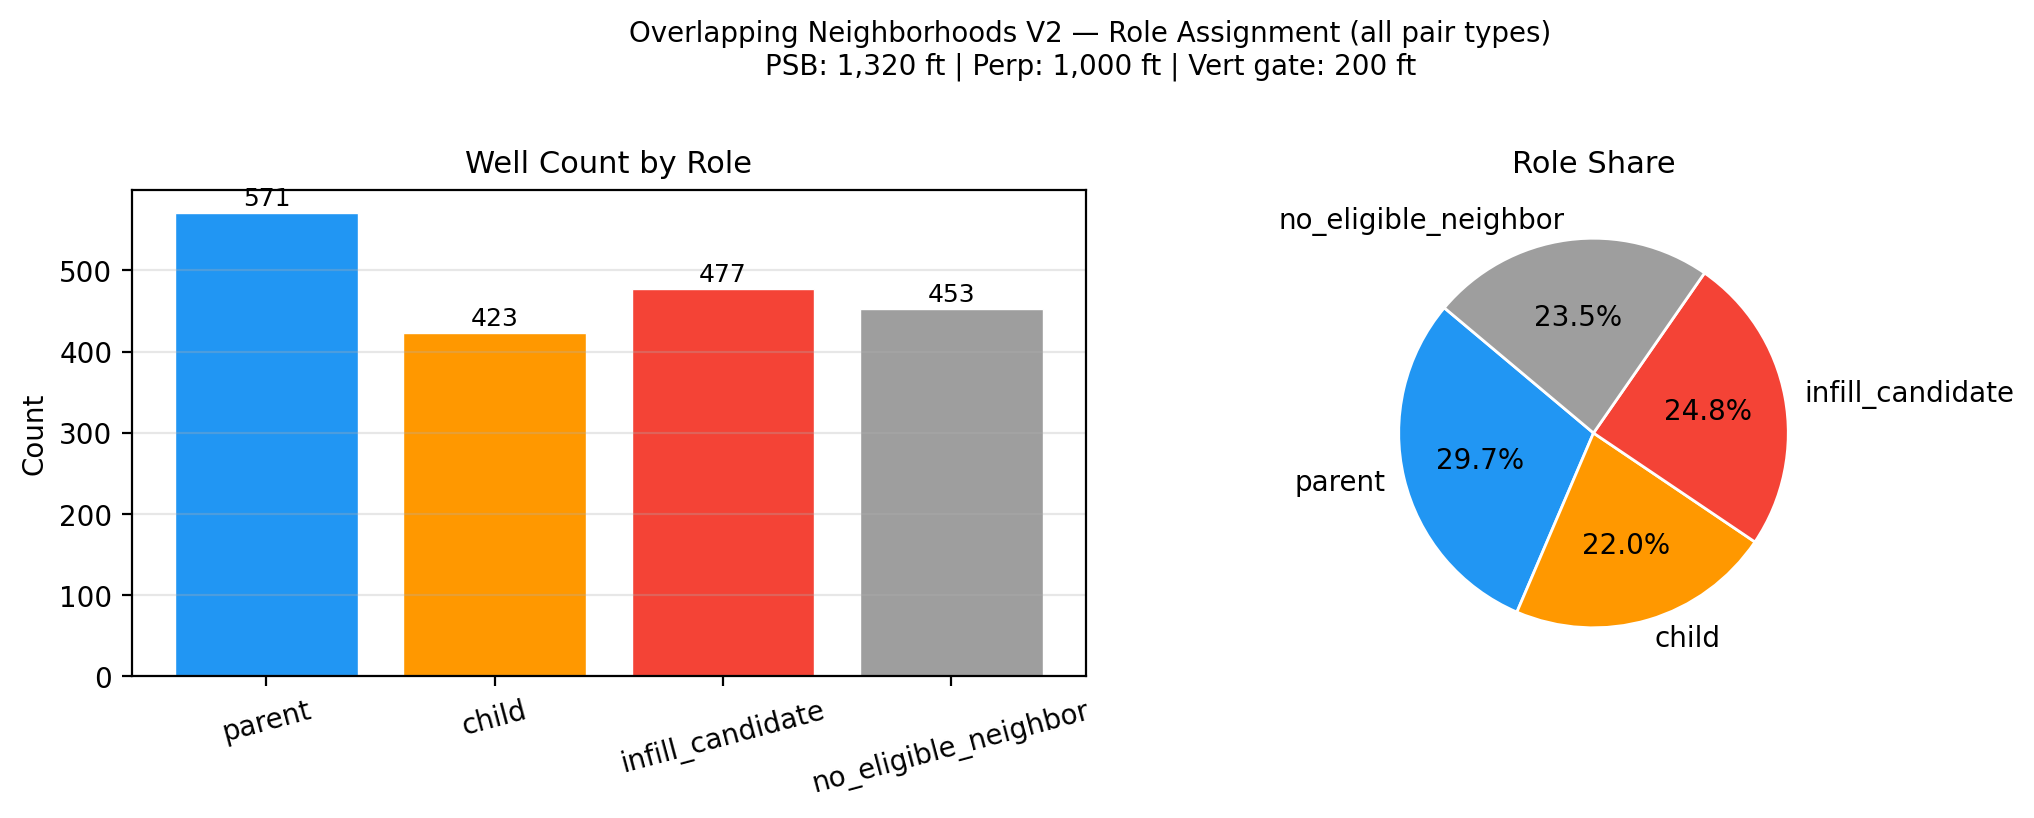

In [8]:
role_counts = df_out['role'].value_counts()
role_labels_ordered = ['parent', 'child', 'infill_candidate', 'no_eligible_neighbor']
role_counts = role_counts.reindex(
    [r for r in role_labels_ordered if r in role_counts.index]
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
ax = axes[0]
bars = ax.bar(
    role_counts.index,
    role_counts.values,
    color=[ROLE_COLORS.get(r, '#607D8B') for r in role_counts.index],
    edgecolor='white', linewidth=0.5,
)
for bar, count in zip(bars, role_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f'{count:,}',
        ha='center', va='bottom', fontsize=9,
    )
ax.set_title('Well Count by Role', fontsize=11)
ax.set_ylabel('Count')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)

# Pie chart
ax = axes[1]
ax.pie(
    role_counts.values,
    labels=role_counts.index,
    colors=[ROLE_COLORS.get(r, '#607D8B') for r in role_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},
)
ax.set_title('Role Share', fontsize=11)

plt.suptitle(
    f'Overlapping Neighborhoods V2 — Role Assignment (all pair types)\n'
    f'PSB: {CFG["parallel_eps_ft"]:,} ft | '
    f'Perp: {CFG["perp_eps_ft"]:,} ft | '
    f'Vert gate: {CFG["cross_bench_vertical_gate_ft"]:,} ft',
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.show()

### 5.2  Parent Distance Distribution (children only) + Parent Pair Type Breakdown (V2)

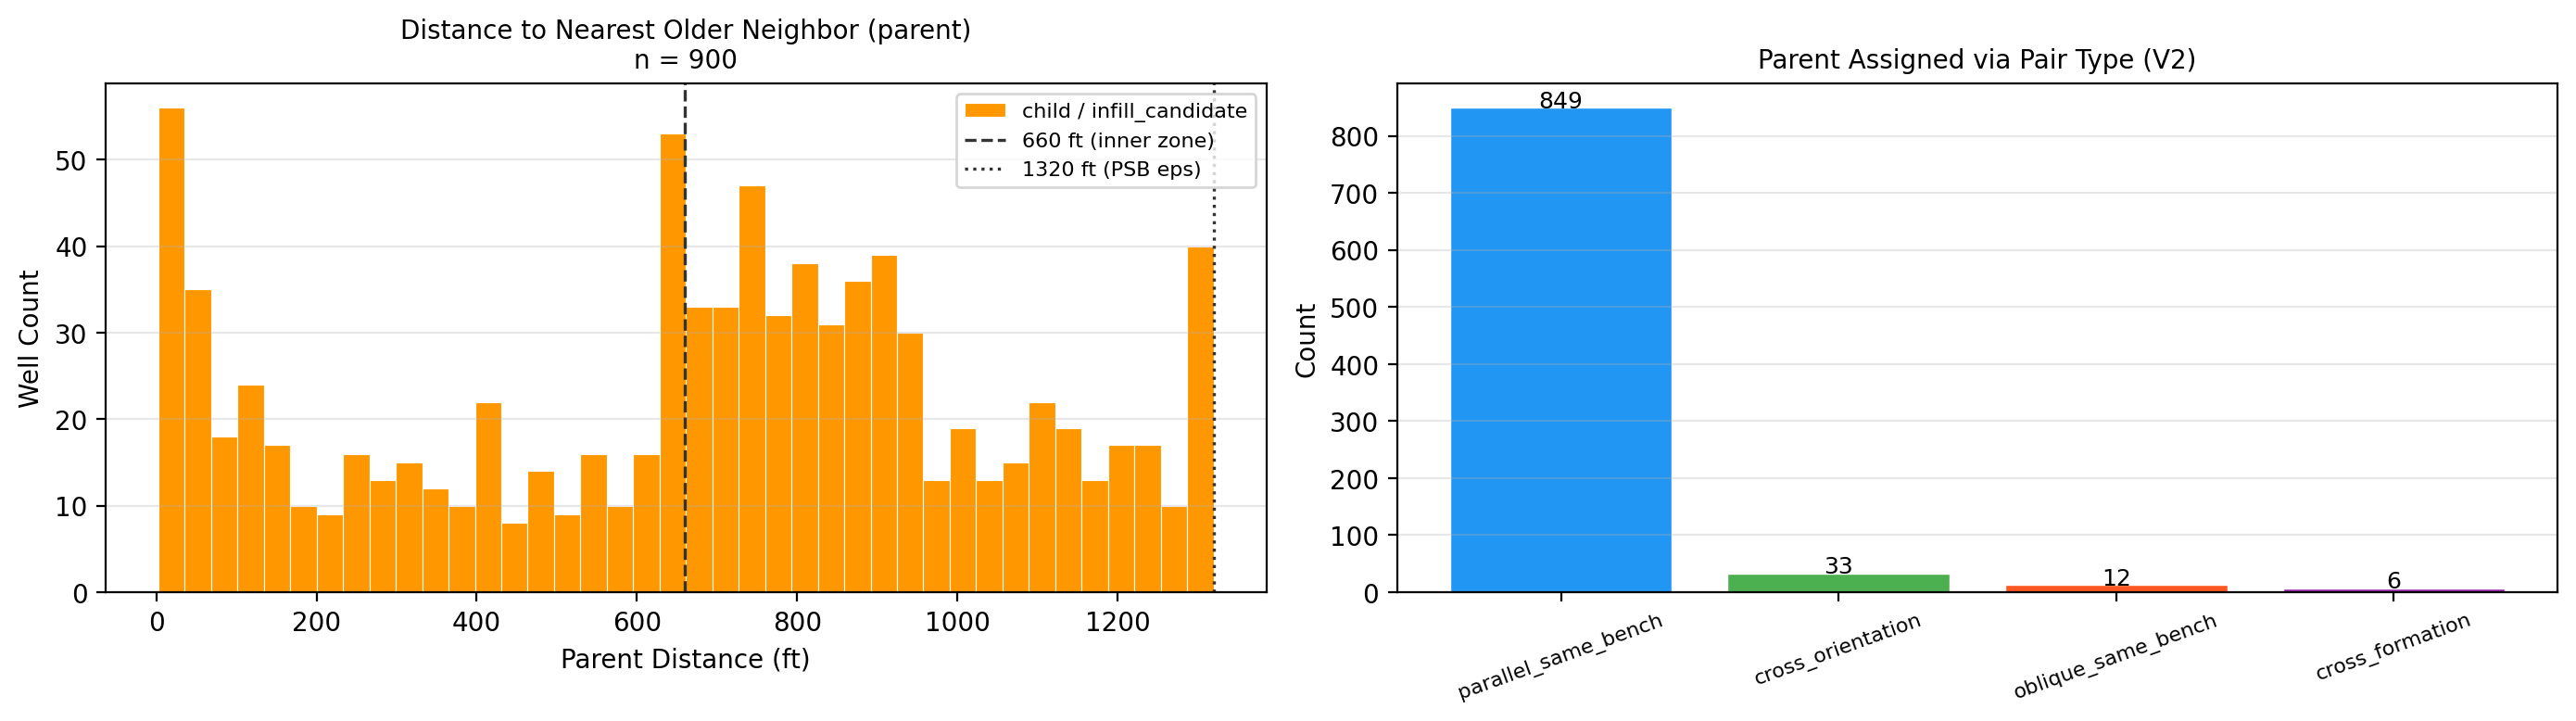

count     900.0
mean      670.0
std       379.1
min         2.6
25%       364.0
50%       728.1
75%       929.6
max     1,319.9


In [9]:
df_children = df_out[df_out['role'].isin(['child', 'infill_candidate'])].dropna(subset=['parent_dist_ft'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: distance histogram
ax = axes[0]
ax.hist(
    df_children['parent_dist_ft'],
    bins=40,
    color='#FF9800', edgecolor='white', linewidth=0.4,
    label='child / infill_candidate',
)
for xval, label, ls in [
    (CFG['inner_zone_ft'], f"{CFG['inner_zone_ft']} ft (inner zone)",  '--'),
    (CFG['parallel_eps_ft'], f"{CFG['parallel_eps_ft']} ft (PSB eps)", ':'),
]:
    ax.axvline(xval, color='#333', linestyle=ls, linewidth=1.2, label=label)
ax.set_xlabel('Parent Distance (ft)', fontsize=10)
ax.set_ylabel('Well Count', fontsize=10)
ax.set_title(f'Distance to Nearest Older Neighbor (parent)\nn = {len(df_children):,}', fontsize=10)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Right: parent pair type breakdown (V2 — shows which pair types assigned parents)
ax = axes[1]
if 'parent_pair_type' in df_children.columns:
    ppt = df_children['parent_pair_type'].value_counts()
    colors = {
        'parallel_same_bench': '#2196F3',
        'cross_formation': '#9C27B0',
        'cross_orientation': '#4CAF50',
        'oblique_same_bench': '#FF5722',
        'oblique_cross_bench': '#795548',
    }
    ax.bar(
        ppt.index, ppt.values,
        color=[colors.get(r, '#607D8B') for r in ppt.index],
        edgecolor='white', linewidth=0.5,
    )
    for i, (name, count) in enumerate(ppt.items()):
        ax.text(i, count + 1, f'{count:,}', ha='center', fontsize=9)
    ax.set_title('Parent Assigned via Pair Type (V2)', fontsize=10)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(df_children['parent_dist_ft'].describe().to_string())

### 5.3  Neighbor Count Distribution by Role

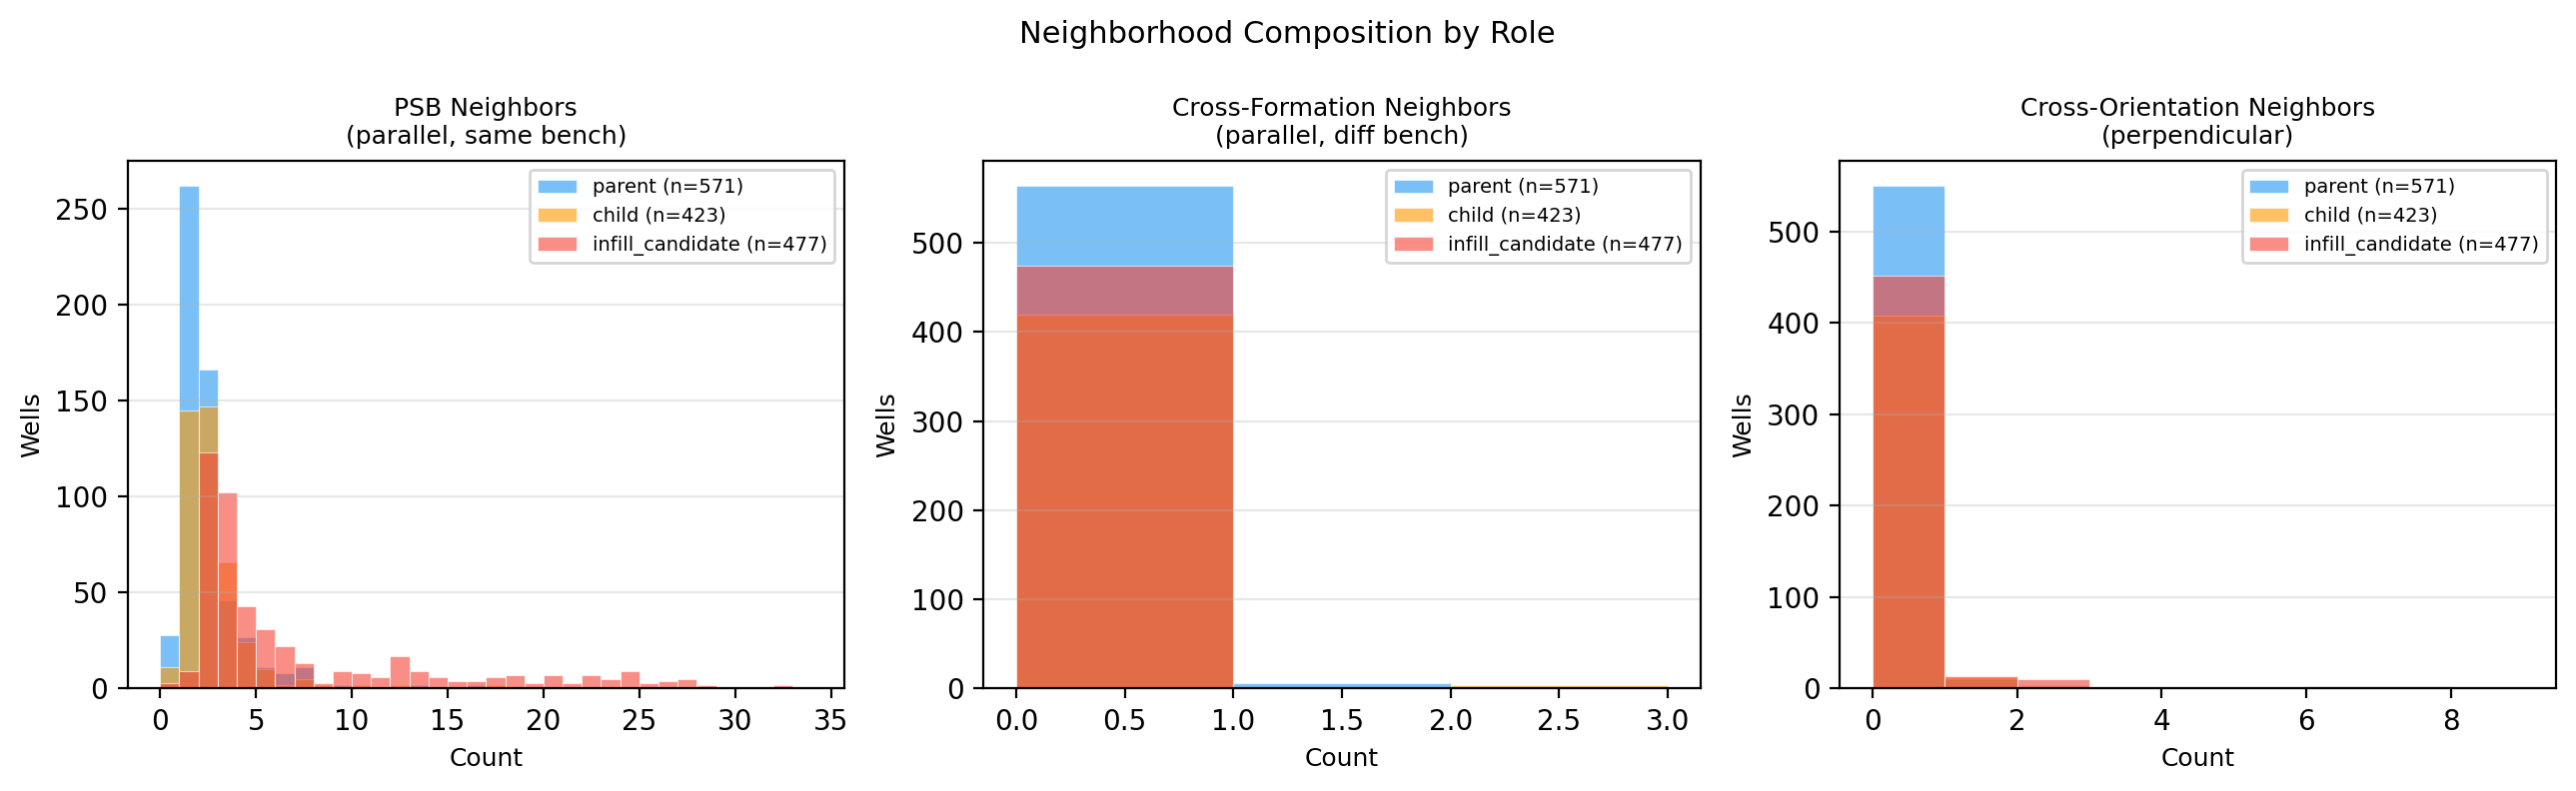

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

count_cols = [
    ('n_parallel_same_bench',  'PSB Neighbors\n(parallel, same bench)'),
    ('n_cross_formation',      'Cross-Formation Neighbors\n(parallel, diff bench)'),
    ('n_cross_orientation',    'Cross-Orientation Neighbors\n(perpendicular)'),
]

roles_to_plot = ['parent', 'child', 'infill_candidate']

for ax, (col, title) in zip(axes, count_cols):
    if col not in df_out.columns:
        ax.set_title(f'{title}\n(column not found)', fontsize=9)
        continue
    for role in roles_to_plot:
        sub = df_out[df_out['role'] == role][col].dropna()
        if sub.empty:
            continue
        ax.hist(
            sub,
            bins=range(0, int(sub.max()) + 2),
            alpha=0.6,
            color=ROLE_COLORS[role],
            label=f'{role} (n={len(sub):,})',
            edgecolor='white', linewidth=0.4,
        )
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Count', fontsize=9)
    ax.set_ylabel('Wells', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Neighborhood Composition by Role', fontsize=11)
plt.tight_layout()
plt.show()

### 5.4  Geographic Map — Wells Colored by Role

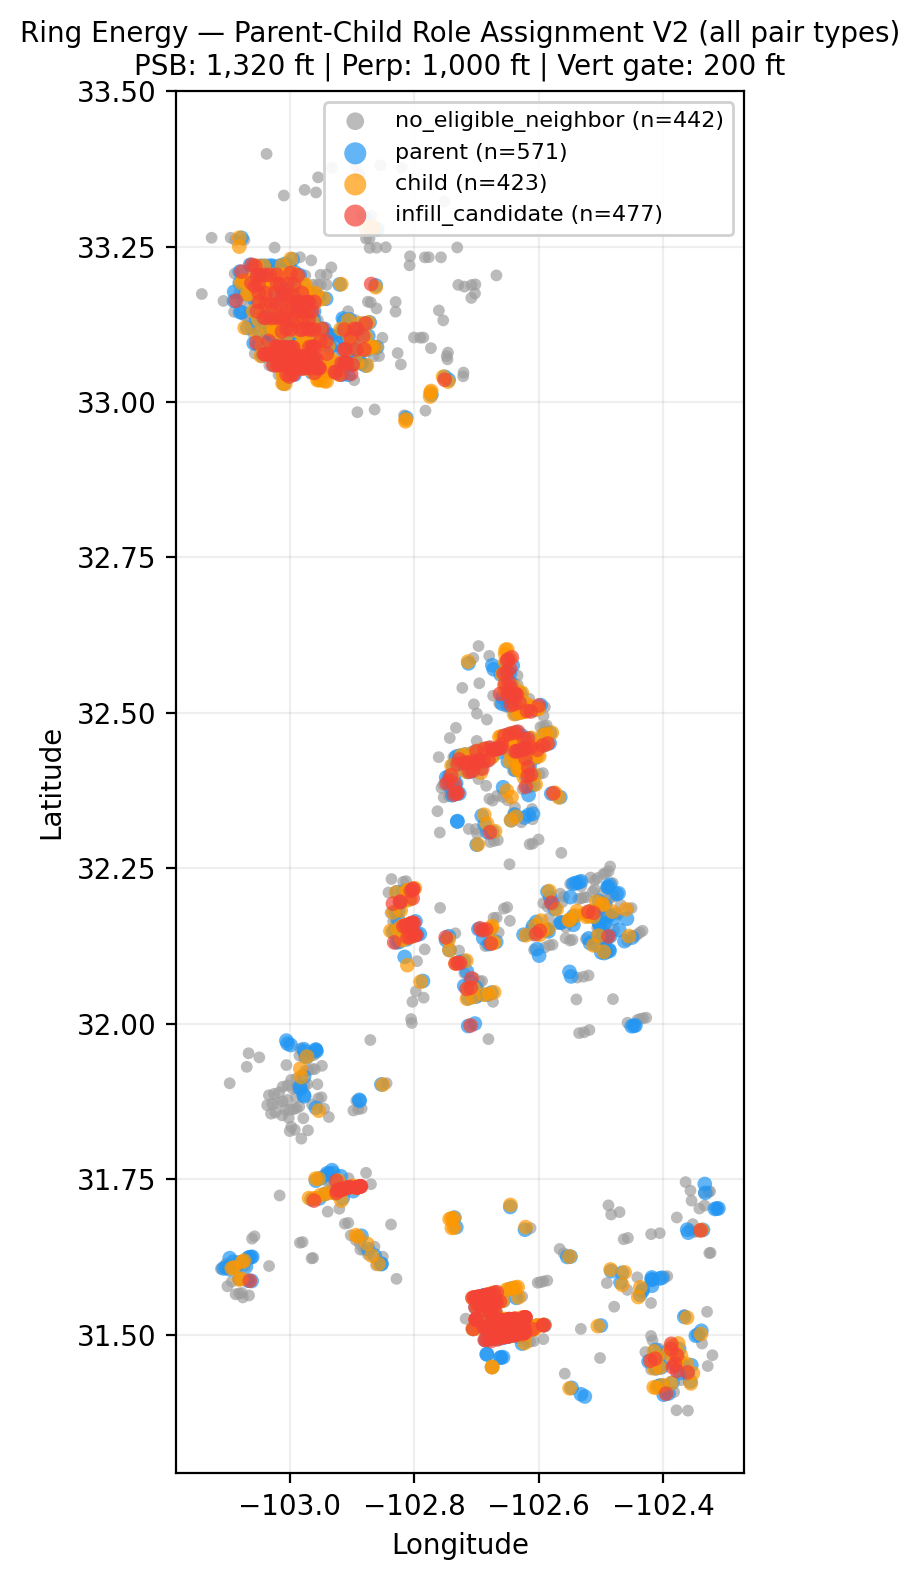

In [11]:
df_map = df_out.dropna(subset=['mid_Lat', 'mid_Lon'])

fig, ax = plt.subplots(figsize=(11, 8))

for role in ['no_eligible_neighbor', 'parent', 'child', 'infill_candidate']:
    sub = df_map[df_map['role'] == role]
    if sub.empty:
        continue
    ax.scatter(
        sub['mid_Lon'], sub['mid_Lat'],
        c=ROLE_COLORS[role],
        s=18 if role == 'no_eligible_neighbor' else 28,
        alpha=0.7,
        label=f'{role} (n={len(sub):,})',
        edgecolors='none',
        zorder=3 if role != 'no_eligible_neighbor' else 1,
    )

ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.set_title(
    'Ring Energy — Parent-Child Role Assignment V2 (all pair types)\n'
    f'PSB: {CFG["parallel_eps_ft"]:,} ft | '
    f'Perp: {CFG["perp_eps_ft"]:,} ft | '
    f'Vert gate: {CFG["cross_bench_vertical_gate_ft"]:,} ft',
    fontsize=10,
)
ax.legend(fontsize=8, markerscale=1.5, framealpha=0.9)
ax.grid(True, alpha=0.2)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 5.5  Role Breakdown by Bench (Formation)

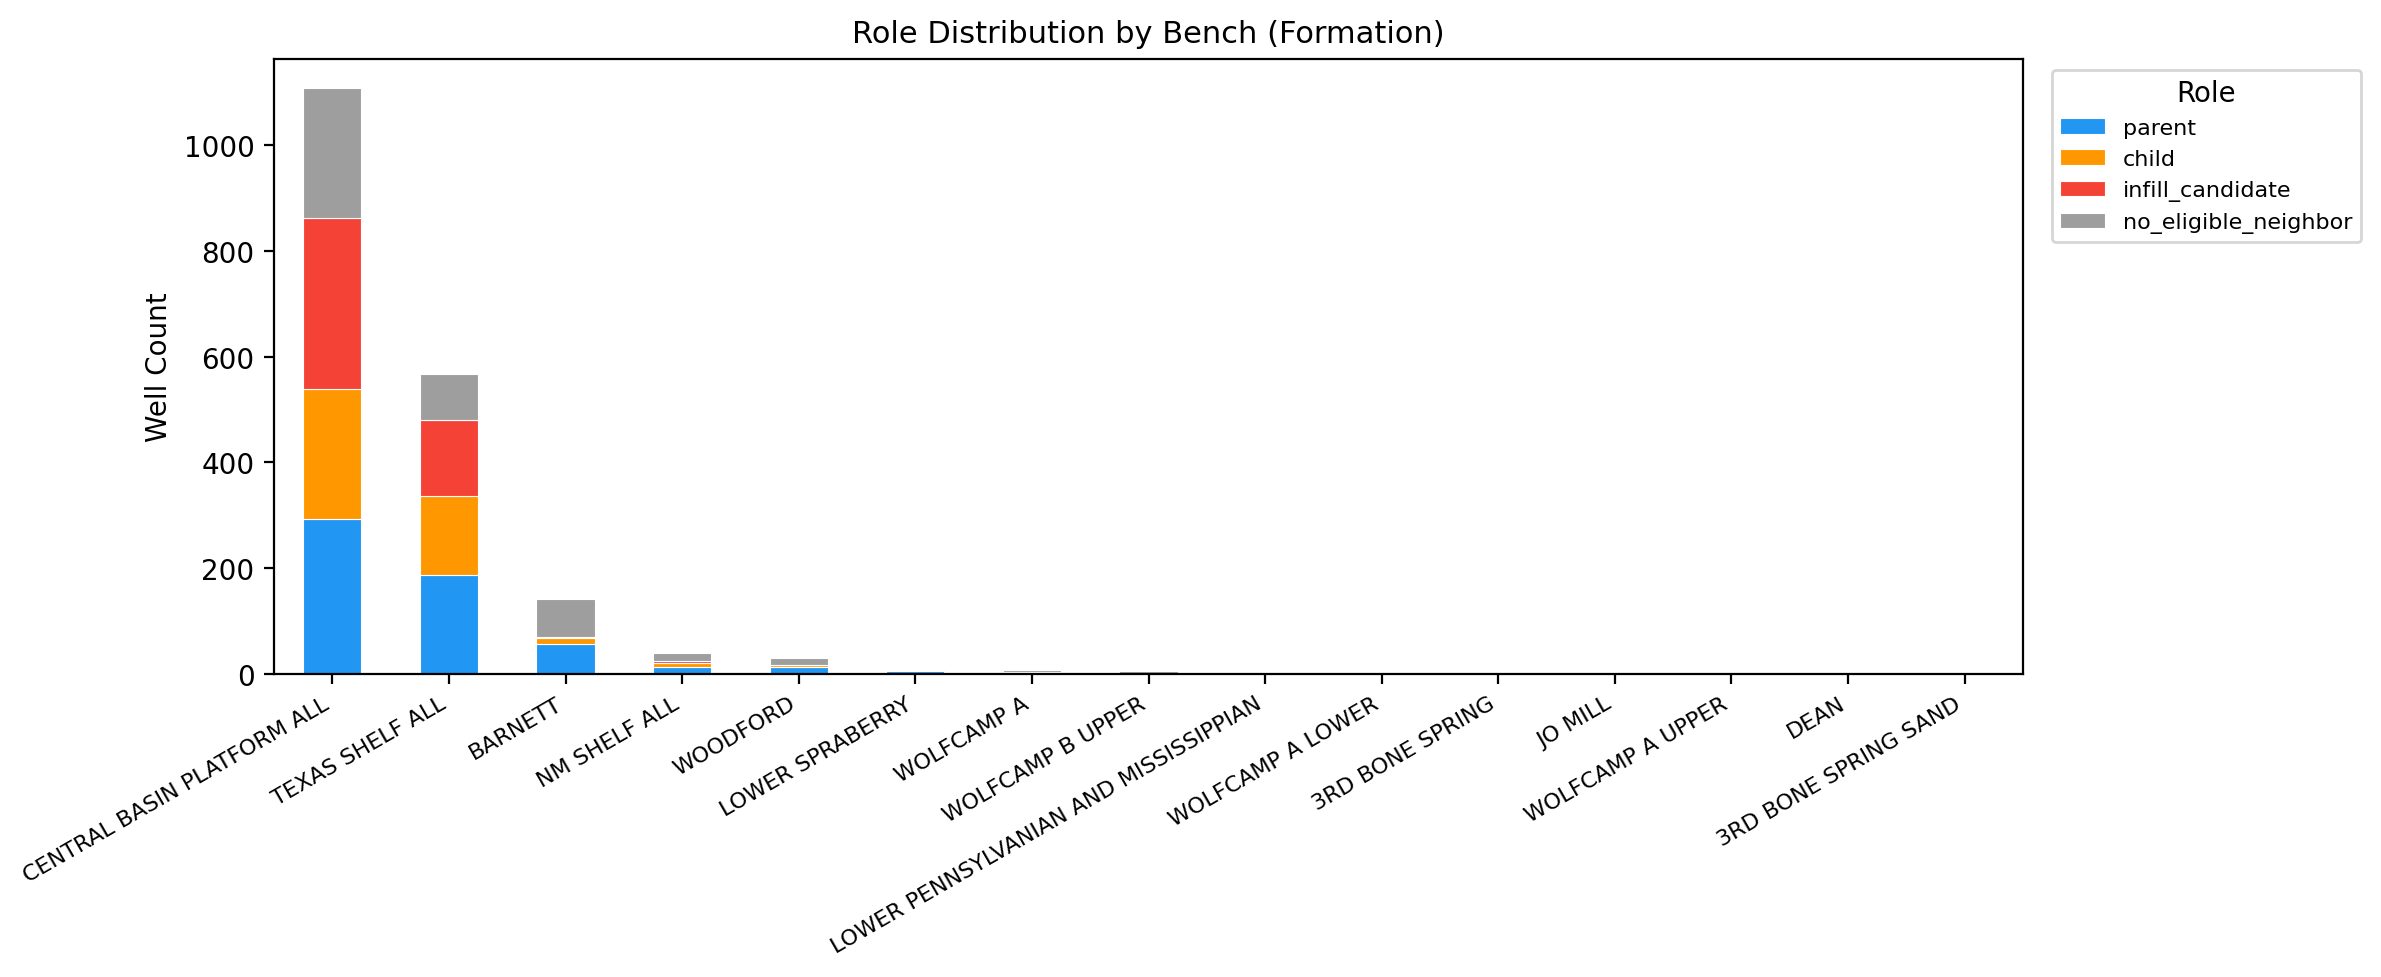

Role share per bench (%):
role                                   parent  child  infill_candidate  no_eligible_neighbor
bench                                                                                       
CENTRAL BASIN PLATFORM ALL               26.4   22.3              29.2                  22.1
TEXAS SHELF ALL                          32.9   26.2              25.5                  15.3
BARNETT                                  39.7    8.5               1.4                  50.4
NM SHELF ALL                             33.3   20.5              10.3                  35.9
WOODFORD                                 40.0   13.3               3.3                  43.3
LOWER SPRABERRY                          66.7    0.0              11.1                  22.2
WOLFCAMP A                               25.0   12.5               0.0                  62.5
WOLFCAMP B UPPER                          0.0    0.0               0.0                 100.0
LOWER PENNSYLVANIAN AND MISSISSIPPIAN     0.

In [12]:
role_labels_ordered = ['parent', 'child', 'infill_candidate', 'no_eligible_neighbor']

pivot = (
    df_out.groupby(['bench', 'role'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[r for r in role_labels_ordered if r in df_out['role'].unique()], fill_value=0)
)

# Sort by total wells per bench
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

pivot.plot(
    kind='bar',
    stacked=True,
    color=[ROLE_COLORS.get(c, '#607D8B') for c in pivot.columns],
    edgecolor='white', linewidth=0.4,
    figsize=(12, 5),
)
plt.title('Role Distribution by Bench (Formation)', fontsize=11)
plt.xlabel('')
plt.ylabel('Well Count')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.legend(title='Role', fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

pct = pivot.div(pivot.sum(axis=1), axis=0).mul(100).round(1)
print('Role share per bench (%):')
print(pct.to_string())

### 5.6  Temporal Profile — Completion Year by Role

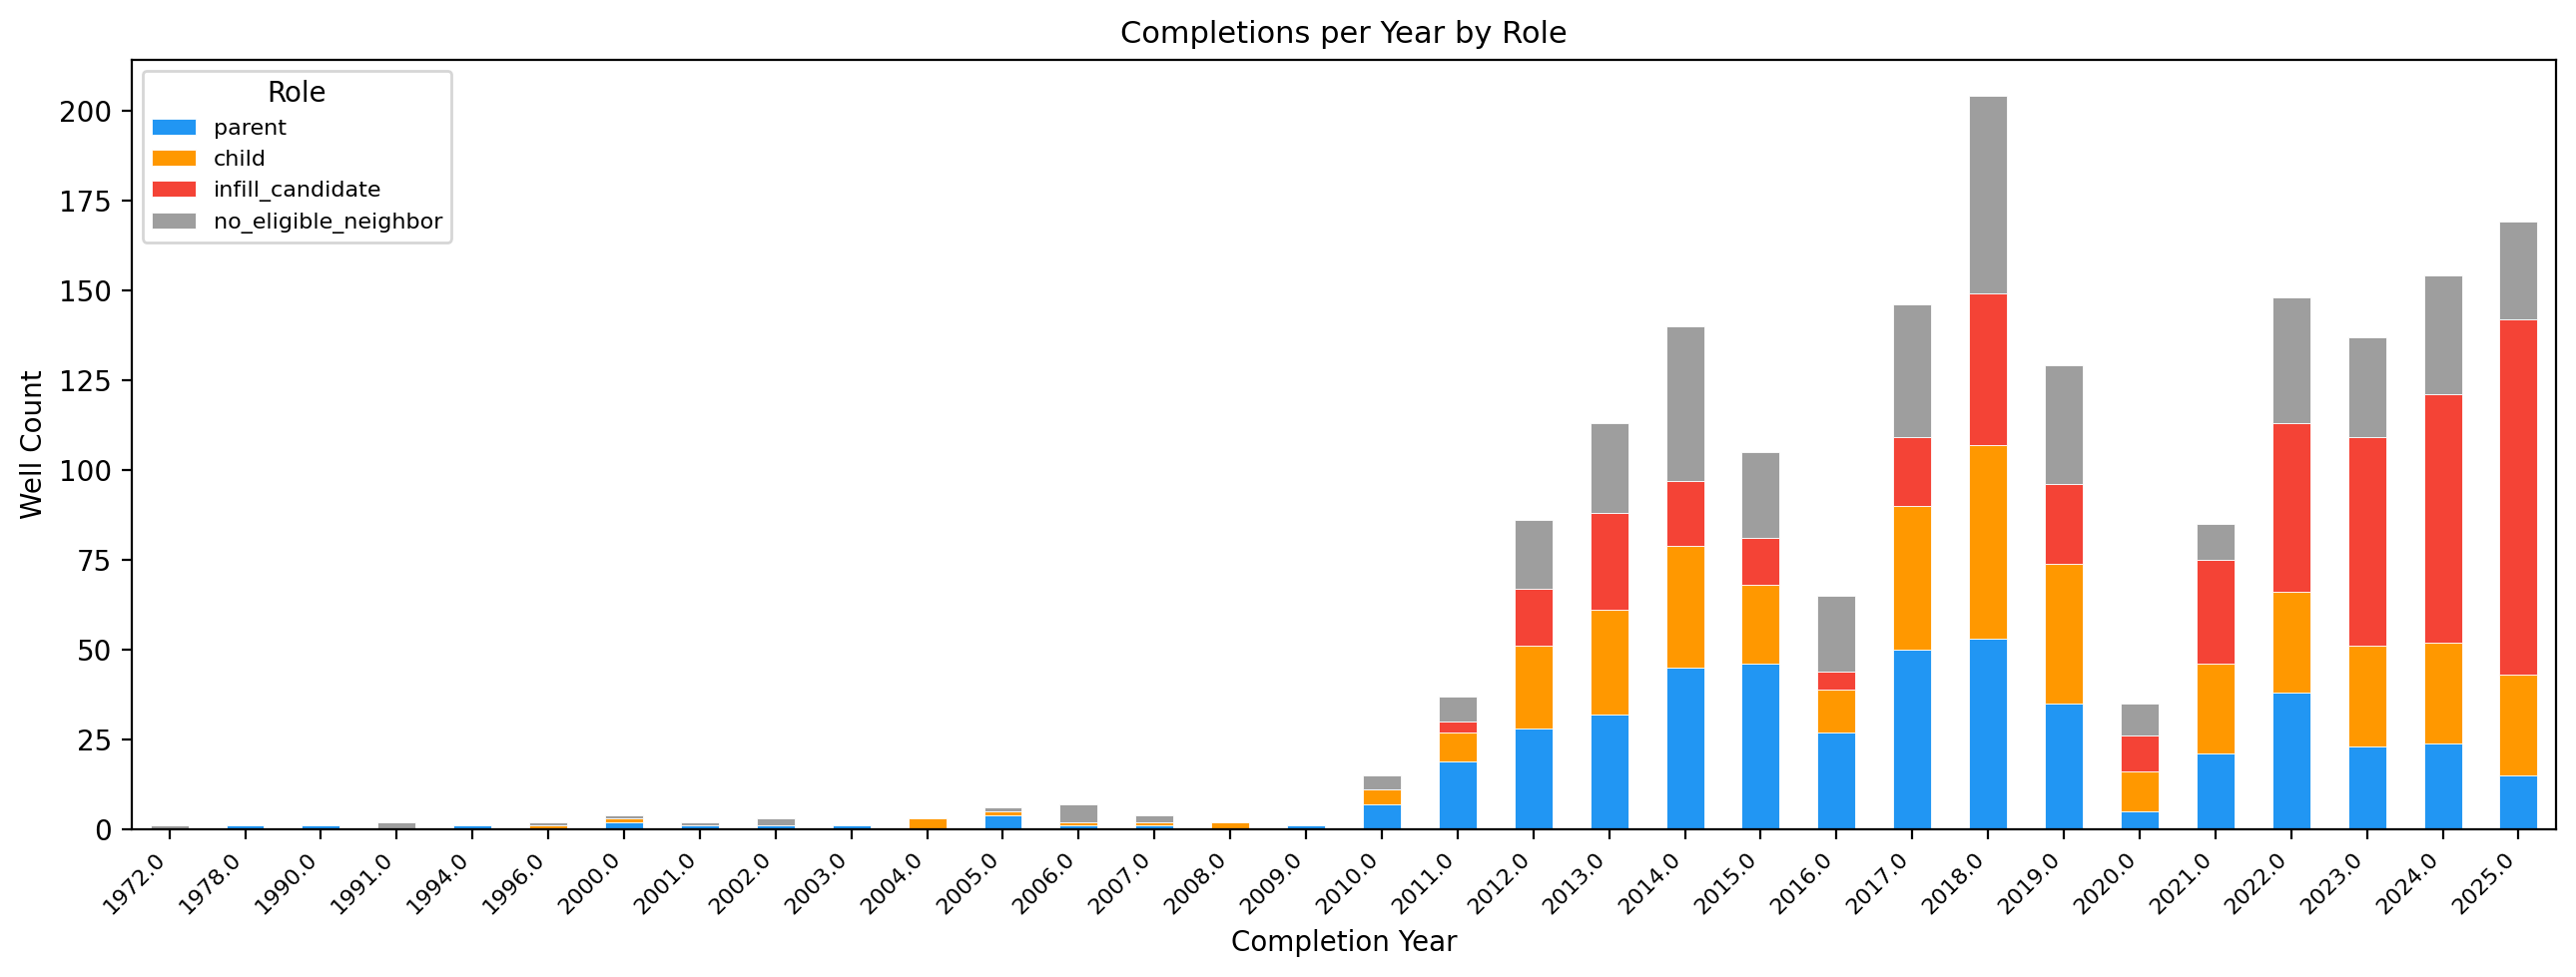

In [13]:
role_labels_ordered = ['parent', 'child', 'infill_candidate', 'no_eligible_neighbor']

df_out['comp_year'] = df_out['comp_date'].dt.year

pivot_year = (
    df_out.dropna(subset=['comp_year'])
    .groupby(['comp_year', 'role'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[r for r in role_labels_ordered if r in df_out['role'].unique()], fill_value=0)
)

pivot_year.plot(
    kind='bar',
    stacked=True,
    color=[ROLE_COLORS.get(c, '#607D8B') for c in pivot_year.columns],
    edgecolor='white', linewidth=0.3,
    figsize=(13, 5),
)
plt.title('Completions per Year by Role', fontsize=11)
plt.xlabel('Completion Year')
plt.ylabel('Well Count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.legend(title='Role', fontsize=8)
plt.tight_layout()
plt.show()

## 6. Diagnostics — Sample Neighborhood Detail

Uses the class's built-in `print_neighborhood()` method for validation.

In [14]:
# Example: pick first parent well for demo
example_uwi = df_out[df_out['role'] == 'parent']['uwi'].iloc[0]
roles_engine.print_neighborhood(example_uwi)

print()
# Example: pick first child well
example_child = df_out[df_out['role'] == 'child']['uwi'].iloc[0]
roles_engine.print_neighborhood(example_child)

print()
# Example: pick first infill candidate
example_infill = df_out[df_out['role'] == 'infill_candidate']['uwi'].iloc[0]
roles_engine.print_neighborhood(example_infill)


Focal well: 42003385790000
  Name:        STATE FI 11H
  Bench:       CENTRAL BASIN PLATFORM ALL
  Comp date:   2000-04-15
  Role:        parent
  Eligible neighbors:  2
  Older eligible:      0
  Inner zone (<660 ft): 2
  cross_orientation: 2

  Neighbor detail (2 total):
        well_k          rel_type confidence  dist_for_threshold  vertical_dist  angle_deg                    bench_k comp_date_k  k_is_older
42003482220000 cross_orientation     medium                23.1           77.4       85.0 CENTRAL BASIN PLATFORM ALL  2021-07-22       False
42003470010000 cross_orientation     medium               562.1          103.0       87.1 CENTRAL BASIN PLATFORM ALL  2015-12-19       False


Focal well: 42501370590000
  Name:        BRUSHY BILL 707-730 2XH
  Bench:       TEXAS SHELF ALL
  Comp date:   2019-01-20
  Role:        child (late_child)
  Parent:      42501368000000 @ 1206 ft  [parallel_same_bench]  (conf: high)
  Child is ABOVE parent  (vert sep: 25 ft)
  Eligible neighbors:  

In [15]:
# Access the neighborhood edge table from the class
df_nbhd = roles_engine.neighborhood_pairs
print(f'Neighborhood pairs: {len(df_nbhd):,}')
df_nbhd

Neighborhood pairs: 5,731


,well_i,well_k,bench_i,bench_k,LL_i,LL_k,overlap_pct_i,overlap_pct_k,tvd_i,tvd_k,hz_effective,3D_dist_effective,vertical_dist,angle_deg,pair_alignment,min_distance_ft,same_bench,rel_type,dist_for_threshold,threshold_ft,vert_gate_ft,in_neighborhood,comp_date_i,comp_date_k,k_is_older,days_diff,confidence
0,30025421210000,30025426220000,NM SHELF ALL,NM SHELF ALL,"4,322.0","4,335.5",1.0,1.0,"5,378.9","5,404.9","1,251.2","1,251.5",26.1,2.1,parallel_like,NaN,True,parallel_same_bench,"1,251.2",1320,NaN,True,2014-12-04,2015-08-25,False,-264.0,high
10,30025426220000,30025421210000,NM SHELF ALL,NM SHELF ALL,"4,335.5","4,322.0",1.0,1.0,"5,404.9","5,378.9","1,251.3","1,251.5",26.1,2.1,parallel_like,NaN,True,parallel_same_bench,"1,251.3",1320,NaN,True,2015-08-25,2014-12-04,True,264.0,high
33,30025449160000,30025453300000,NM SHELF ALL,NM SHELF ALL,"5,210.4","5,033.3",0.0,0.0,"5,183.2","5,203.2","1,243.6","1,243.8",20.0,2.4,parallel_like,NaN,True,parallel_same_bench,"1,243.6",1320,NaN,True,2018-08-01,2019-01-31,False,-183.0,high
36,30025449160000,30025463300000,NM SHELF ALL,NM SHELF ALL,"5,210.4","5,187.4",1.0,1.0,"5,183.2","5,162.6","1,096.5","1,096.7",20.6,2.5,parallel_like,NaN,True,parallel_same_bench,"1,096.5",1320,NaN,True,2018-08-01,2019-11-09,False,-465.0,high
116,30025463300000,30025449160000,NM SHELF ALL,NM SHELF ALL,"5,187.4","5,210.4",1.0,1.0,"5,162.6","5,183.2","1,097.0","1,097.2",20.6,2.5,parallel_like,NaN,True,parallel_same_bench,"1,097.0",1320,NaN,True,2019-11-09,2018-08-01,True,465.0,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96221,42501370610000,42501373980000,TEXAS SHELF ALL,TEXAS SHELF ALL,"4,471.3","5,231.6",0.0,0.0,"5,295.7","5,373.1","1,154.1","1,156.7",77.4,2.8,parallel_like,NaN,True,parallel_same_bench,"1,154.1",1320,NaN,True,2019-01-30,2022-10-06,False,"-1,345.0",high
96280,42501373090000,42501374030000,TEXAS SHELF ALL,TEXAS SHELF ALL,"5,156.2","5,437.5",0.0,0.0,"5,287.1","5,329.4",252.3,255.8,42.3,2.6,parallel_like,NaN,True,parallel_same_bench,252.3,1320,NaN,True,2021-11-13,2022-10-26,False,-347.0,high
96786,42501374030000,42501374250000,TEXAS SHELF ALL,TEXAS SHELF ALL,"5,437.5","5,167.8",0.0,0.0,"5,329.4","5,345.3",779.8,779.9,15.9,2.8,parallel_like,NaN,True,parallel_same_bench,779.8,1320,NaN,True,2022-10-26,2023-05-01,False,-187.0,high
98227,42501366990000,42501375540000,TEXAS SHELF ALL,TEXAS SHELF ALL,"5,262.3","7,854.7",0.0,0.0,"5,306.9","5,295.4",405.0,405.2,11.5,1.5,parallel_like,NaN,True,parallel_same_bench,405.0,1320,NaN,True,2016-08-28,2024-08-23,False,"-2,917.0",high


In [16]:
df_out

,uwi,well_name,lease_name,operator,bench,comp_date,role,child_gen,parent_uwi,parent_dist_ft,parent_pair_type,parent_confidence,parent_vertical_ft,child_above_parent,parent_comp_date,days_since_parent,n_eligible_neighbors,n_older_eligible,n_inner_zone_neighbors,n_parallel_same_bench,n_cross_formation,n_cross_formation_pre_existing,n_cross_formation_post,min_dist_cross_formation_ft,n_cross_orientation,n_cross_orientation_pre_existing,n_cross_orientation_post,min_dist_cross_orientation_ft,n_oblique_same_bench,n_oblique_same_bench_pre_existing,n_oblique_same_bench_post,min_dist_oblique_same_bench_ft,n_oblique_cross_bench,role_contributing_types,dominant_pair_type,first_prod_date,lateral_length_ft,tvd,surface_lat,surface_lon,fluid_intensity_bbl_per_ft,proppant_intensity_lbs_per_ft,cum_oil_180d,cum_oil_365d,cum_oil_180d_per_ft,cum_oil_365d_per_ft,rsv_cat,group_size,neighbors_in_group,avg_hz_spacing_ft,mid_Lat,mid_Lon,comp_year
0,42501367160100,SLIM HONEYCUTT 608 4XH,SLIM HONEYCUTT 608,RILEY EXPLORATION PERMIAN,TEXAS SHELF ALL,2017-01-17,no_eligible_neighbor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,0,0,0,0,0,0,0,NaN,0,0,0,NaN,0,0,0,NaN,0,NaN,NaN,2017-01-01,"4,638.0","5,311.7",33.1,-102.9,5.4,NaN,"2,119.0","2,971.0",0.5,0.6,01PDP,1.0,0.0,NaN,33.1,-102.9,"2,017.0"
1,42003385790000,STATE FI 11H,STATE FI,LIME ROCK,CENTRAL BASIN PLATFORM ALL,2000-04-15,parent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,2,0,2,0,0,0,0,NaN,2,0,2,23.1,0,0,0,NaN,0,NaN,NaN,2000-04-01,"1,869.0","10,683.1",32.1,-102.6,NaN,NaN,"1,975.0","5,955.0",1.1,3.2,02PA,1.0,0.0,NaN,32.1,-102.6,"2,000.0"
2,42475389480000,KING GEORGE 7705WH,KING GEORGE,CONOCOPHILLIPS,WOODFORD,NaT,no_eligible_neighbor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,0,0,0,0,0,0,0,NaN,0,0,0,NaN,0,0,0,NaN,0,NaN,NaN,NaT,"14,904.0","14,950.6",31.6,-103.1,NaN,NaN,NaN,NaN,NaN,NaN,03PUD,2.0,1.0,"1,330.2",31.6,-103.1,NaN
3,42103375340000,WADDELL TR A 4049H,WADDELL TR A,BLACKBEARD OPERATING,CENTRAL BASIN PLATFORM ALL,2025-09-15,infill_candidate,NaN,42103373410000,87.9,parallel_same_bench,high,978.7,True,2025-07-31,46.0,25,24,11,25,0,0,0,NaN,0,0,0,NaN,0,0,0,NaN,0,parallel_same_bench,parallel_same_bench,2025-09-01,"11,413.0","3,408.9",31.5,-102.6,4.4,222.2,"17,956.2","17,956.2",1.6,1.6,01PDP,6.0,5.0,"1,088.7",31.5,-102.6,"2,025.0"
4,42475389560000,KING GEORGE 7707WH,KING GEORGE,CONOCOPHILLIPS,WOODFORD,NaT,parent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,1,0,0,1,0,0,0,NaN,0,0,0,NaN,0,0,0,NaN,0,NaN,NaN,NaT,"15,035.0","14,815.6",31.6,-103.1,NaN,NaN,NaN,NaN,NaN,NaN,03PUD,3.0,2.0,"1,320.7",31.6,-103.1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1919,42165324830100,WHARTON UNIT 113,WHARTON UNIT,MACH NATURAL RESOURCES LP,CENTRAL BASIN PLATFORM ALL,NaT,parent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,1,0,1,0,0,0,0,NaN,1,0,1,48.5,0,0,0,NaN,0,NaN,NaN,1983-03-01,"1,021.0","5,954.5",32.6,-102.7,NaN,NaN,NaN,NaN,NaN,NaN,02PDNP,1.0,0.0,NaN,32.6,-102.7,NaN
1920,42003034550100,SHAFTER LAKE /SAN ANDRES/ UNIT 96W,SHAFTER LAKE /SAN ANDRES/ UNIT,HILCORP,CENTRAL BASIN PLATFORM ALL,2010-10-18,no_eligible_neighbor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,0,0,0,0,0,0,0,NaN,0,0,0,NaN,0,0,0,NaN,0,NaN,NaN,1968-02-01,"2,312.0","4,625.7",32.3,-102.6,NaN,NaN,NaN,NaN,NaN,NaN,02PA,1.0,0.0,NaN,32.3,-102.6,"2,010.0"
1921,42003434610100,UNIVERSITY 24A 3,UNIVERSITY 24A,CRESCENT ENERGY COMPANY,CENTRAL BASIN PLATFORM ALL,NaT,no_eligible_neighbor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,0,0,0,0,0,0,0,NaN,0,0,0,NaN,0,0,0,NaN,0,NaN,NaN,2011-10-01,"1,763.0","4,517.7",32.2,-102.6,NaN,NaN,NaN,NaN,NaN,NaN,02PA,1.0,0.0,NaN,32.2,-102.6,NaN
1922,42003416510100,UNIVERSITY BLOCK 9 8A,UNIVERSITY BLOCK 9,EXXON,CENTRAL BASIN PLATFORM ALL,2015-09-03,no_eligible_neighbor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,0,0,0,0,0,0,0,NaN,0,0,0,NaN,0,0,0,NaN,0,NaN,NaN,2010-09-01,"2,560.0","10,607.7",32.2,-102.6,NaN,NaN,576.7,928.8,0.2,0.4,02PA,1.0,0

## 7. Export

In [17]:
out_path = CFG['output_dir'] / 'overlapping_neighborhoods_roles_v2.csv'
df_out.to_csv(out_path, index=False)
print(f'Saved {len(df_out):,} rows -> {out_path}')

# Also save the full neighborhood edge table (useful for network analysis / dashboard)
df_nbhd = roles_engine.neighborhood_pairs
nbhd_edge_path = CFG['output_dir'] / 'overlapping_neighborhoods_edges_v2.csv'
edge_cols = [
    'well_i', 'well_k', 'rel_type', 'confidence',
    'dist_for_threshold', 'threshold_ft', 'vertical_dist',
    'angle_deg', 'pair_alignment',
    'bench_i', 'bench_k',
    'overlap_pct_i', 'overlap_pct_k',
    'comp_date_i', 'comp_date_k',
    'k_is_older', 'days_diff',
]
edge_cols = [c for c in edge_cols if c in df_nbhd.columns]
df_nbhd[edge_cols].to_csv(nbhd_edge_path, index=False)
print(f'Saved {len(df_nbhd):,} neighborhood edges -> {nbhd_edge_path}')

Saved 1,924 rows -> C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\03. Ring Energy\04. Spacing Results\v2\overlapping_neighborhoods_roles_v2.csv
Saved 5,731 neighborhood edges -> C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\03. Ring Energy\04. Spacing Results\v2\overlapping_neighborhoods_edges_v2.csv


---
## Summary

This notebook implements the **Overlapping Neighborhoods V2** approach for parent-child
well role assignment using the `OverlappingNeighborhoodRoles` class.

### V2 Changes from V1
- **All five pair types** participate in role assignment by default (not just PSB)
- **Cross-bench vertical gate** (configurable, default 200 ft) controls when cross-formation
  pairs qualify for role assignment
- **Parent pair type tracking** — output shows which pair type assigned each parent
  (parallel_same_bench, cross_formation, cross_orientation, oblique_same_bench, oblique_cross_bench)
- **Confidence levels** (high / medium / low) per pair type for downstream filtering
- **child_above_parent** flag — captures vertical asymmetry (SPE-223524: WCA child above depleted
  WCB parent shows worse asymmetric frac growth)
- **User toggles** — enable/disable any pair type via `role_pair_types` dict

### Outputs
| File | Description |
|---|---|
| `overlapping_neighborhoods_roles_v2.csv` | One row per well with role, parent info (incl. pair type + confidence), and cross-interference counts |
| `overlapping_neighborhoods_edges_v2.csv` | Neighborhood edge table with confidence tags |

### Key Literature Supporting V2
- **URTeC-2024-4019465** (HFTS-2): Frac height crosses bench boundaries; parent depletion alters child frac geometry
- **SPE-223524-PA** (2025): Cross-bench parent-child is real; WCA child wells show asymmetric growth after parent depletion
- **URTeC-3722340** (2022): Multi-bench interference measured in Delaware Basin field observations
- **SPE 25HFTC** (2025): Multi-bench child well placement explicitly treated as parent-child problem

### Class Location
`src/well_data/well_role_assignment.py` -> `OverlappingNeighborhoodRoles`